# Lifetime Inversion with Gaussian Process Regression

This notebook demonstrates `GPRegression` — inversion of a PALS spectrum into a continuous lifetime distribution $f(\tau)$ using a Gaussian process.

**The model.** The measured spectrum is
$$y(t) = N \cdot \sum_j \mathrm{RM}_{tj}\, c_j + \mathrm{bg}, \qquad c_j = e^{g_j},$$
where each column of the response matrix $\mathrm{RM}$ is the IRF-convolved decay for one $\tau_j$ (sum-normalized), $c$ are probability weights, and $N$ is a free total-counts amplitude. The log-distribution $g(\tau)$ carries a GP prior with an RBF kernel on $\log\tau$:
$$g \sim \mathcal{GP}\big(\log(1/n_\tau),\; \sigma^2 e^{-(\Delta\log\tau)^2/2\ell^2}\big).$$

Working in log space makes positivity structural, and the kernel on $\log\tau$ matches the physics: exponential components are distinguishable by their *ratio*, not their difference.

**Why GP?** Three properties make it natural for lifetime spectra:
1. $f(\tau) > 0$ by construction — no positivity constraints needed;
2. the posterior is a distribution, so it provides **calibrated error bars** on $f(\tau)$;
3. the kernel length scale $\ell$ is selected by the **marginal likelihood (evidence)** — so the resolution of the reconstruction is set by the information content of the data, not by hand.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from pyPAS.core.time_resolution import MultiGaussianRF
from pyPAS.core.lifetime import PASLifetime
from pyPAS.model.lifetime import LifetimeModel
from pyPAS.analysis.lifetime import (
    generate_random_lt_spectrum,
    TikhonovRegularization,
    MaximalEntropyInversion,
    GPRegression,
)
from scispectrum import Spectrum

np.random.seed(42)

## 1. Synthetic spectrum

Ground truth: two Gaussian peaks in $f(\tau)$ at $\tau = 0.4$ ns (70%) and $\tau = 2.0$ ns (30%). The IRF is a Gaussian with FWHM 230 ps, and the spectrum holds $10^6$ events over a flat background.

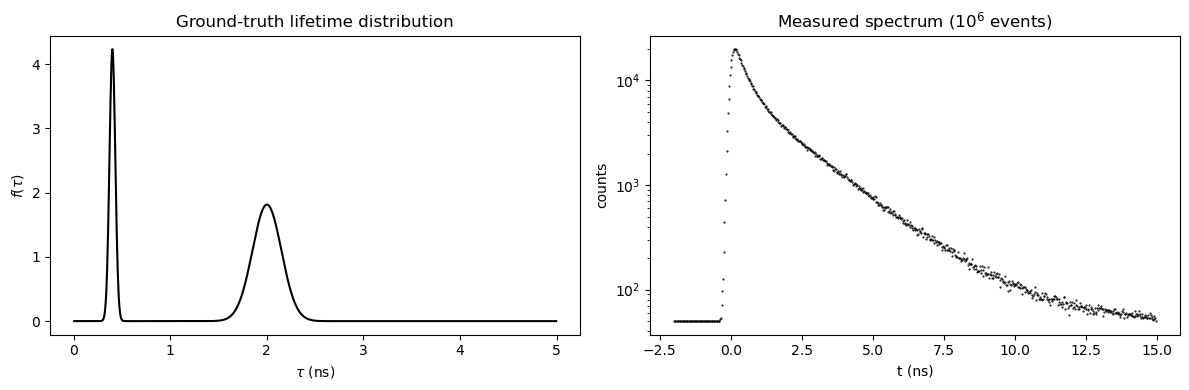

In [2]:
time = np.arange(-2, 15, 0.025)                     # ns
irf_sigma = np.array([0.230 / (2 * np.sqrt(2 * np.log(2)))])
irf = MultiGaussianRF(irf_sigma, np.ones_like(irf_sigma), np.zeros_like(irf_sigma))

tau_fine = np.arange(0.005, 5, 0.005)
truth = np.zeros_like(tau_fine)
for tau_c, w, sig in [(0.4, 0.7, 0.03), (2.0, 0.3, 0.15)]:
    truth += w * np.exp(-((tau_fine - tau_c) ** 2) / (2 * sig ** 2))
truth /= np.trapezoid(truth, tau_fine)

model = LifetimeModel("two-peak", lifetimes=tau_fine, intensities=truth)
bg = 50.0
r = generate_random_lt_spectrum(time, model, irf, num_events=1_000_000)
pals = PASLifetime(
    lifetime=Spectrum(counts=r.lifetime.counts + bg, axis_calib=r.lifetime.axis_calib),
    resolution=irf,
)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(tau_fine, truth, 'k-')
axes[0].set_xlabel(r'$\tau$ (ns)'); axes[0].set_ylabel(r'$f(\tau)$')
axes[0].set_title('Ground-truth lifetime distribution')
axes[1].semilogy(time, pals.lifetime.counts, 'k.', ms=1)
axes[1].set_xlabel('t (ns)'); axes[1].set_ylabel('counts')
axes[1].set_title('Measured spectrum ($10^6$ events)')
plt.tight_layout()

## 2. GP inversion

`invert` selects the kernel hyperparameters $(\ell, \text{amplitude})$ by maximizing the Laplace approximation of the evidence,
$$-\log Z \approx \tfrac{1}{2}\chi^2 + \tfrac{1}{2}(g-m)^T K^{-1}(g-m) + \tfrac{1}{2}\log\det(I + K W),$$
on a grid traversed smooth$\to$flexible with warm starts. The log-det term is the Occam penalty — extra flexibility must be paid for by a better fit. Models within 1 nat of the best evidence are treated as ties and the smoothest is kept.

In [3]:
tau_grid = np.arange(0.05, 4.5, 0.02)

gp = GPRegression(pals.lifetime.energy.values, tau_grid)
f_gp, meta = gp.invert(pals, bg_est=bg)

print(f"selected length scale ell = {meta['length_scale']:.2f}")
print(f"selected log amplitude   = {meta['log_amplitude']:.1f}")
print(f"-log evidence            = {meta['neg_log_evidence']:.1f}")

selected length scale ell = 0.14
selected log amplitude   = 3.0
-log evidence            = 219.9


## 3. Comparison with Tikhonov and MELT

In [4]:
tik = TikhonovRegularization(pals.lifetime.energy.values, tau_grid)
f_tik, _ = tik.invert(pals, bg_est=bg)

melt = MaximalEntropyInversion(pals.lifetime.energy.values, tau_grid)
_, f_melt = melt.invert(pals, bg_est=bg)

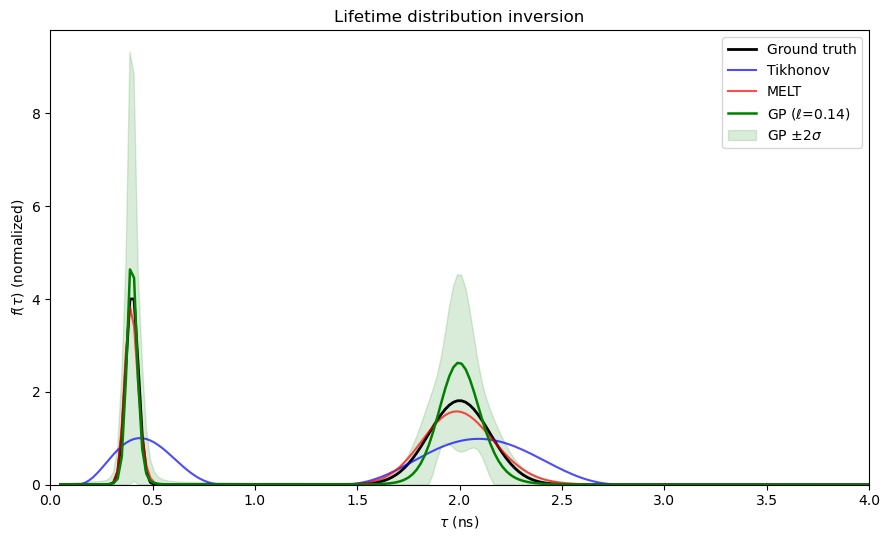

In [5]:
truth_g = np.interp(tau_grid, tau_fine, truth)
truth_g /= np.trapezoid(truth_g, tau_grid)

norm = np.trapezoid(f_gp, tau_grid)
f_gp_n, std_n = f_gp / norm, meta['posterior_std'] / norm
f_tik_n = f_tik / np.trapezoid(f_tik, tau_grid)
f_melt_n = f_melt / np.trapezoid(f_melt, tau_grid)

plt.figure(figsize=(9, 5.5))
plt.plot(tau_grid, truth_g, 'k-', lw=2, label='Ground truth')
plt.plot(tau_grid, f_tik_n, 'b-', lw=1.5, alpha=0.7, label='Tikhonov')
plt.plot(tau_grid, f_melt_n, 'r-', lw=1.5, alpha=0.7, label='MELT')
plt.plot(tau_grid, f_gp_n, 'g-', lw=1.8, label=f"GP ($\\ell$={meta['length_scale']:.2f})")
plt.fill_between(tau_grid, np.clip(f_gp_n - 2 * std_n, 0, None), f_gp_n + 2 * std_n,
                 color='g', alpha=0.15, label=r'GP $\pm 2\sigma$')
plt.xlabel(r'$\tau$ (ns)'); plt.ylabel(r'$f(\tau)$ (normalized)')
plt.legend(); plt.xlim(0, 4); plt.ylim(bottom=0)
plt.title('Lifetime distribution inversion')
plt.tight_layout()

Both peak centers are recovered exactly; the GP additionally reports its pointwise uncertainty (shaded). Tikhonov over-smooths both peaks.

## 4. Evidence diagnostics

`metadata['evidence_grid']` stores $-\log Z$ for every grid point — useful to verify the selection is an interior optimum (amplitude direction) and to see the plateau below the resolution limit ($\ell$ direction).

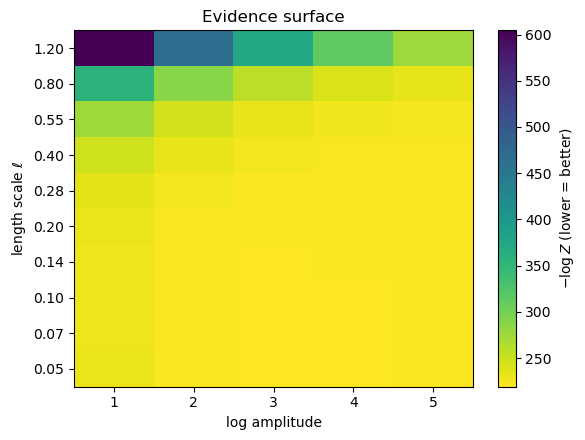

In [6]:
grid = meta['evidence_grid']
ells = sorted({e for e, a, v in grid}, reverse=True)
amps = sorted({a for e, a, v in grid})
surface = np.array([[dict(((aa, vv) for ee, aa, vv in grid if ee == e))[a]
                     for a in amps] for e in ells])

plt.figure(figsize=(6, 4.5))
plt.imshow(surface, aspect='auto', cmap='viridis_r',
           extent=[min(amps) - 0.5, max(amps) + 0.5, 0, len(ells)])
plt.yticks(np.arange(len(ells)) + 0.5, [f'{e:.2f}' for e in reversed(ells)])
plt.xlabel('log amplitude'); plt.ylabel(r'length scale $\ell$')
plt.colorbar(label=r'$-\log Z$ (lower = better)')
plt.title('Evidence surface')
plt.tight_layout()

## 5. Resolution adapts to statistics

The hardest situation for exponential inversion is a close doublet at long lifetimes — e.g. $\tau = 1.6$ and $2.4$ ns: the decays $e^{-t/1.6}$ and $e^{-t/2.4}$ are nearly proportional over the measurement window. With $10^6$ events no method can split them. But the GP's evidence re-selects the length scale as statistics improve, and the doublet emerges — while MELT keeps merging it at any count level.

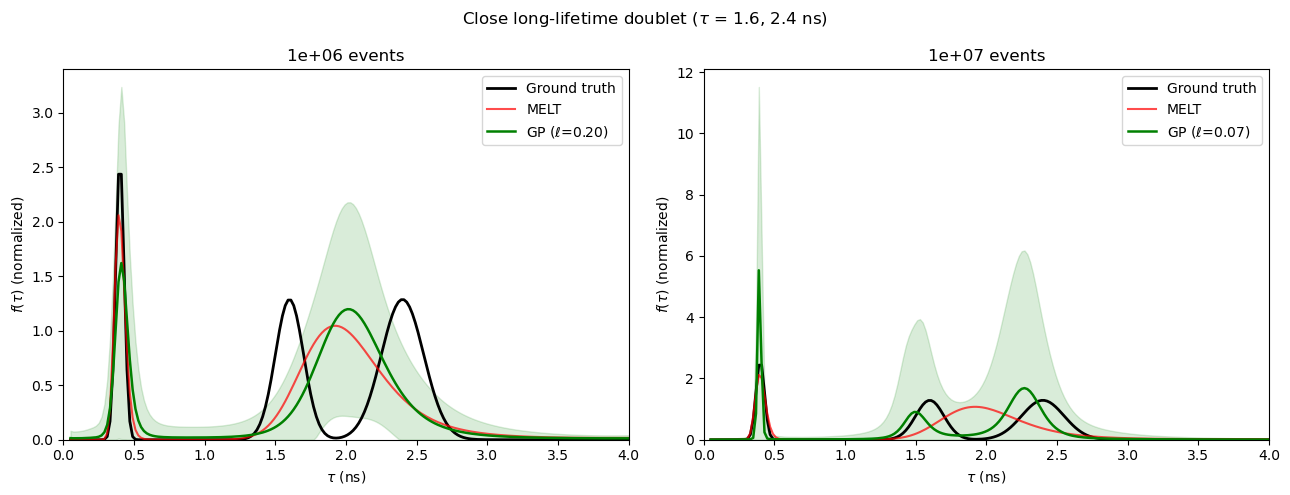

In [7]:
components = [(0.40, 0.50, 0.03), (1.60, 0.25, 0.10), (2.40, 0.25, 0.15)]
truth_A = np.zeros_like(tau_fine)
for tau_c, w, sig in components:
    truth_A += w * np.exp(-((tau_fine - tau_c) ** 2) / (2 * sig ** 2))
truth_A /= np.trapezoid(truth_A, tau_fine)
model_A = LifetimeModel("doublet", lifetimes=tau_fine, intensities=truth_A)

truth_A_g = np.interp(tau_grid, tau_fine, truth_A)
truth_A_g /= np.trapezoid(truth_A_g, tau_grid)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, n_events in zip(axes, [1_000_000, 10_000_000]):
    r = generate_random_lt_spectrum(time, model_A, irf, num_events=n_events)
    pals_A = PASLifetime(
        lifetime=Spectrum(counts=r.lifetime.counts + bg,
                          axis_calib=r.lifetime.axis_calib),
        resolution=irf,
    )

    melt_A = MaximalEntropyInversion(pals_A.lifetime.energy.values, tau_grid)
    _, fm = melt_A.invert(pals_A, bg_est=bg)

    gp_A = GPRegression(pals_A.lifetime.energy.values, tau_grid)
    fg, mA = gp_A.invert(pals_A, bg_est=bg)

    fm_n = fm / np.trapezoid(fm, tau_grid)
    nrm = np.trapezoid(fg, tau_grid)
    fg_n, sg_n = fg / nrm, mA['posterior_std'] / nrm

    ax.plot(tau_grid, truth_A_g, 'k-', lw=2, label='Ground truth')
    ax.plot(tau_grid, fm_n, 'r-', lw=1.5, alpha=0.7, label='MELT')
    ax.plot(tau_grid, fg_n, 'g-', lw=1.8, label=f"GP ($\\ell$={mA['length_scale']:.2f})")
    ax.fill_between(tau_grid, np.clip(fg_n - 2 * sg_n, 0, None), fg_n + 2 * sg_n,
                    color='g', alpha=0.15)
    ax.set_xlabel(r'$\tau$ (ns)'); ax.set_ylabel(r'$f(\tau)$ (normalized)')
    ax.set_title(f'{n_events:.0e} events')
    ax.legend(); ax.set_xlim(0, 4); ax.set_ylim(bottom=0)
plt.suptitle(r'Close long-lifetime doublet ($\tau$ = 1.6, 2.4 ns)')
plt.tight_layout()

At $10^6$ events the evidence selects a large $\ell$ — the reconstruction honestly reports a single broad component, and the $\pm 2\sigma$ band is wide there. At $10^7$ events the evidence supports a small $\ell$ and the doublet separates, with the uncertainty band shrinking accordingly.

## 6. Fixed hyperparameters

Skipping the evidence grid makes the inversion run in seconds — useful when processing many spectra with the same settings, or for exploring the effect of $\ell$ manually.

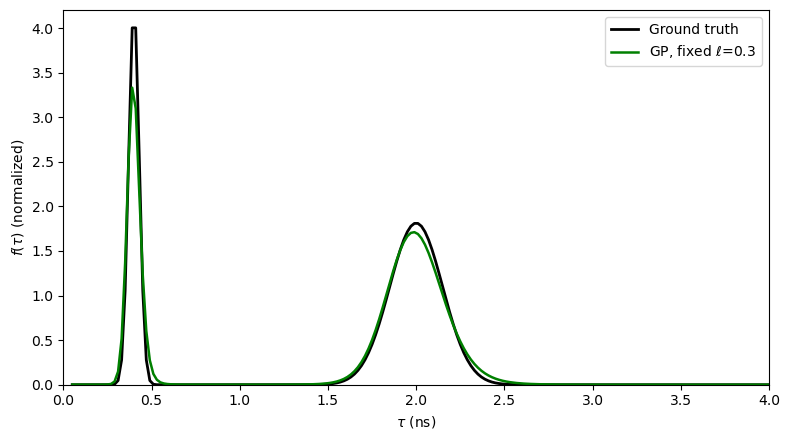

In [8]:
f_fix, meta_fix = gp.invert(pals, bg_est=bg, optimize_hyperparams=False,
                            length_scale=0.3, log_amplitude=3.0)
f_fix_n = f_fix / np.trapezoid(f_fix, tau_grid)

plt.figure(figsize=(8, 4.5))
plt.plot(tau_grid, truth_g, 'k-', lw=2, label='Ground truth')
plt.plot(tau_grid, f_fix_n, 'g-', lw=1.8, label=r'GP, fixed $\ell$=0.3')
plt.xlabel(r'$\tau$ (ns)'); plt.ylabel(r'$f(\tau)$ (normalized)')
plt.legend(); plt.xlim(0, 4); plt.ylim(bottom=0)
plt.tight_layout()